# 1. Fetching SwissProt human proteome, sampling 300k random peptides of len 8-12 (MHCI) and 300k 15-25 (MHCII)

In [1]:
from pathlib import Path
import subprocess
import numpy as np 
import random as rand
import pandas as pd
import time
from typing import List, Dict
import json

import time
#import requests
from Bio.Align import substitution_matrices
from Bio import Entrez
from Bio import SeqIO
import matplotlib.pyplot as plt
import logomaker

In [1]:
"""
Download the Human Swiss-Prot Proteome from UniProt REST API
============================================================
- Proteome: UP000005640 (Homo sapiens reference proteome)
- Database: Swiss-Prot only (reviewed=true)
- Formats: FASTA + TSV metadata
- API: https://rest.uniprot.org
 
Usage:
    pip install requests tqdm
    python download_human_swissprot.py
"""
 
import requests
import json
import time
import sys
from pathlib import Path
 
# ──────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────
BASE_URL    = "https://rest.uniprot.org/uniprotkb"
PROTEOME_ID = "UP000005640"           # Human reference proteome
QUERY       = f"proteome:{PROTEOME_ID} AND reviewed:true"   # Swiss-Prot only
 
DIR = Path('/home/aalarkin/Work/AnchorMiner/datasets/human_proteome')
FASTA_FILE  = Path(f"{DIR}/human_swissprot.fasta")
TSV_FILE    = Path(f"{DIR}/human_swissprot_metadata.tsv")
JSON_FILE   = Path(f"{DIR}/human_swissprot_metadata.json")
 
# Fields to retrieve in TSV/JSON download
TSV_FIELDS  = ",".join([
    "accession",
    "id",
    "gene_names",
    "protein_name",
    "organism_name",
    "length",
    "mass",
    "sequence",
    "reviewed",
    "annotation_score",
    "cc_function",
    "go_f",       # GO molecular function
    "go_p",       # GO biological process
    "go_c",       # GO cellular component
    "xref_pdb",   # PDB cross-references
    "ft_signal",  # Signal peptide
    "ft_transmem",# Transmembrane regions
    "keyword",    # UniProt keywords
])
 
PAGE_SIZE   = 500    # entries per page (max 500)
 
 
# ──────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────
 
def make_session() -> requests.Session:
    """Create a session with a descriptive User-Agent."""
    s = requests.Session()
    s.headers.update({"User-Agent": "Python/UniProt-HumanProteome-Downloader"})
    return s
 
 
def get_total_count(session: requests.Session, query: str) -> int:
    """Fetch the total number of matching entries."""
    r = session.get(
        f"{BASE_URL}/search",
        params={"query": query, "format": "json", "size": 1},
        timeout=30,
    )
    r.raise_for_status()
    return int(r.headers.get("x-total-results", 0))
 
 
def stream_fasta(session: requests.Session, query: str, out_path: Path) -> int:
    """
    Stream the full FASTA file using the /stream endpoint.
    Returns the number of sequences written.
    """
    print(f"\n[1/2] Downloading FASTA → {out_path}")
    params = {
        "query":            query,
        "format":           "fasta",
        "includeIsoform":   "true",   # include isoforms
        "compressed":       "false",
    }
    with session.get(f"{BASE_URL}/stream", params=params,
                     stream=True, timeout=120) as r:
        r.raise_for_status()
        count = 0
        with open(out_path, "w") as fh:
            for chunk in r.iter_content(chunk_size=1 << 20, decode_unicode=True):
                if chunk:
                    fh.write(chunk)
                    count += chunk.count(">")
        print(f"   ✓  {count:,} sequences written to {out_path}")
    return count
 
 
def paginate_tsv(session: requests.Session, query: str,
                 fields: str, out_path: Path) -> int:
    """
    Paginate through the search endpoint to download TSV metadata.
    Uses the 'Link' header cursor for reliable pagination.
    Returns the number of rows written.
    """
    print(f"\n[2/2] Downloading TSV metadata → {out_path}")
    params = {
        "query":   query,
        "format":  "tsv",
        "fields":  fields,
        "size":    PAGE_SIZE,
    }
    url    = f"{BASE_URL}/search"
    rows   = 0
    page   = 0
    header_written = False
 
    with open(out_path, "w") as fh:
        while url:
            page += 1
            # Only send params on the first request; subsequent URLs are self-contained
            r = session.get(url, params=params if page == 1 else None,
                            timeout=60)
            r.raise_for_status()
 
            lines = r.text.splitlines(keepends=True)
            if not lines:
                break
 
            if not header_written:
                fh.writelines(lines)          # include header on first page
                rows += max(0, len(lines) - 1)
                header_written = True
            else:
                fh.writelines(lines[1:])      # skip duplicate header
                rows += max(0, len(lines) - 1)
 
            # Follow cursor from Link header — use the FULL URL returned
            link = r.headers.get("Link", "")
            url  = _parse_next_link(link)     # returns None when no more pages
 
            print(f"   page {page:3d}  –  {rows:,} entries so far", end="\r")
            time.sleep(0.1)   # be polite to the API
 
    print(f"\n   ✓  {rows:,} rows written to {out_path}")
    return rows
 
 
def _parse_next_link(link_header: str) -> str | None:
    """Extract the 'next' URL from a Link header, if present.
    
    The Link header looks like:
      <https://rest.uniprot.org/uniprotkb/search?...&cursor=XYZ&size=500>; rel="next"
    """
    import re
    # Find all <URL>; rel="next" patterns
    match = re.search(r'<(https?://[^>]+)>\s*;\s*rel="next"', link_header)
    if match:
        return match.group(1)
    return None
 
 
def print_summary(fasta_path: Path, tsv_path: Path) -> None:
    """Print a brief summary of what was downloaded."""
    print("\n" + "═" * 52)
    print("  Download complete")
    print("═" * 52)
    for p in (fasta_path, tsv_path):
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.name:<40} {size_mb:6.1f} MB")
    print("═" * 52)
    print("\nQuick-parse example (Biopython):")
    print("  from Bio import SeqIO")
    print(f'  records = list(SeqIO.parse("{fasta_path}", "fasta"))')
    print("  print(records[0].id, records[0].seq[:50])")
    print("\nQuick-parse example (pandas):")
    print("  import pandas as pd")
    print(f'  df = pd.read_csv("{tsv_path}", sep="\\t")')
    print("  print(df.shape, df.columns.tolist())")
 
 
# ──────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────
 
def main():
    session = make_session()
 
    print("=" * 52)
    print("  UniProt Human Swiss-Prot Proteome Downloader")
    print("=" * 52)
    print(f"  Proteome : {PROTEOME_ID}  (Homo sapiens)")
    print(f"  Database : Swiss-Prot (reviewed)")
    print(f"  API base : {BASE_URL}")
 
    # 1. Count entries
    total = get_total_count(session, QUERY)
    print(f"\n  Total Swiss-Prot human entries: {total:,}")
    if total == 0:
        print("  No entries found – check query / connectivity.")
        sys.exit(1)
 
    # 2. FASTA download via streaming endpoint
    stream_fasta(session, QUERY, FASTA_FILE)
 
    # 3. TSV metadata via paginated search
    paginate_tsv(session, QUERY, TSV_FIELDS, TSV_FILE)
 
    # 4. Summary
    print_summary(FASTA_FILE, TSV_FILE)
 
 
if __name__ == "__main__":
    main()

  UniProt Human Swiss-Prot Proteome Downloader
  Proteome : UP000005640  (Homo sapiens)
  Database : Swiss-Prot (reviewed)
  API base : https://rest.uniprot.org/uniprotkb

  Total Swiss-Prot human entries: 20,416

[1/2] Downloading FASTA → /home/aalarkin/Work/AnchorMiner/datasets/human_proteome/human_swissprot.fasta
   ✓  42,568 sequences written to /home/aalarkin/Work/AnchorMiner/datasets/human_proteome/human_swissprot.fasta

[2/2] Downloading TSV metadata → /home/aalarkin/Work/AnchorMiner/datasets/human_proteome/human_swissprot_metadata.tsv
   page  41  –  20,416 entries so far
   ✓  20,416 rows written to /home/aalarkin/Work/AnchorMiner/datasets/human_proteome/human_swissprot_metadata.tsv

════════════════════════════════════════════════════
  Download complete
════════════════════════════════════════════════════
  human_swissprot.fasta                      29.3 MB
  human_swissprot_metadata.tsv               45.2 MB
════════════════════════════════════════════════════

Quick-parse 

In [ ]:
"""
Random peptide sampling from the human Swiss-Prot proteome.
 
Samples:
  - 600k peptides of length 9–12  
  - 600k peptides of length 15–25 
 
"""
 
import random
from pathlib import Path
from Bio import SeqIO


N_PEPTIDES = 1500000
 
# ── Paths ──────────────────────────────────────────────────────────────────────
DIR       = Path("/home/aalarkin/Work/AnchorMiner/datasets/human_proteome")
FASTA_IN  = DIR / "human_swissprot.fasta"
FASTA_OUT_MHC1 = Path("/home/aalarkin/Work/AnchorMiner/datasets/RunningMHCPan/peptide_samples_mhcI.fasta")
FASTA_OUT_MHC2 = Path("/home/aalarkin/Work/AnchorMiner/datasets/RunningMHCPan/peptide_samples_mhcII.fasta")
PEP_OUT_MHC1 = Path("/home/aalarkin/Work/AnchorMiner/datasets/RunningMHCPan/peptide_samples_mhcI.txt")
PEP_OUT_MHC2 = Path("/home/aalarkin/Work/AnchorMiner/datasets/RunningMHCPan/peptide_samples_mhcII.txt")
PEP_OUT_MHC1_TEST = Path("/home/aalarkin/Work/AnchorMiner/datasets/RunningMHCPan/peptide_samples_mhcI_small.txt")


SEED = 42
 
 
# ── Core sampling function ─────────────────────────────────────────────────────
def sample_peptides(sequences, n, min_len, max_len, rng):
    """
    Draw n random peptides from a list of protein sequences.
    Each peptide is a substring of a randomly chosen protein at a random position.
    Proteins shorter than min_len are skipped.
    """
    # Only keep proteins long enough to yield at least one peptide
    eligible = [s for s in sequences if len(s) >= min_len]
 
    peptides = []
    while len(peptides) < n:
        protein   = rng.choice(eligible)
        pep_len   = rng.randint(min_len, min(max_len, len(protein)))
        start     = rng.randint(0, len(protein) - pep_len)
        peptides.append(str(protein[start : start + pep_len]))
 
    return peptides
 
 
# ── Load proteome ──────────────────────────────────────────────────────────────
print(f"Loading proteome from {FASTA_IN} ...")
sequences = [record.seq for record in SeqIO.parse(FASTA_IN, "fasta")]
print(f"  {len(sequences):,} proteins loaded")
 
rng = random.Random(SEED)
 
# ── Sample ─────────────────────────────────────────────────────────────────────
print("\nSampling {N_PEPTIDES} short peptides  (len 9–12)  ...")
short_peptides = sample_peptides(sequences, N_PEPTIDES, min_len=9,  max_len=12,  rng=rng)
 
print("Sampling {N_PEPTIDES} medium peptides (len 15–25) ...")
medium_peptides = sample_peptides(sequences, N_PEPTIDES, min_len=15, max_len=25, rng=rng)
 
# ── Write FASTA ────────────────────────────────────────────────────────────────
print(f"\nWriting {FASTA_OUT_MHC1} ...")

with open(FASTA_OUT_MHC1, "w") as fh:
    for i, seq in enumerate(short_peptides):
        fh.write(f">mhc1_{i+1} len={len(seq)}\n{seq}\n")


with open(FASTA_OUT_MHC2, "w") as fh:
    for i, seq in enumerate(medium_peptides):
        fh.write(f">mhc2_{i+1} len={len(seq)}\n{seq}\n")


with open(PEP_OUT_MHC1, "w") as fh:
    for i, seq in enumerate(short_peptides):
        fh.write(f"{seq}\n")

with open(PEP_OUT_MHC2, "w") as fh:
    for i, seq in enumerate(medium_peptides):
        fh.write(f"{seq}\n")

 
#test_set = sample_peptides(sequences, 500, min_len=9, max_len=12, rng=rng)


#with open(PEP_OUT_MHC1_TEST, "w") as fh:
#    for i, seq in enumerate(test_set):
#        fh.write(f"{seq}\n")


Loading proteome from /home/aalarkin/Work/AnchorMiner/datasets/human_proteome/human_swissprot.fasta ...
  42,547 proteins loaded

Sampling {N_PEPTIDES} short peptides  (len 9–12)  ...
Sampling {N_PEPTIDES} medium peptides (len 15–25) ...

Writing /home/aalarkin/Work/AnchorMiner/datasets/RunningMHCPan/peptide_samples_mhcI.fasta ...


NameError: name 'test_set' is not defined

# 2. Fetching HLA
### 2.1 First dataset ~ test: buckley et al

In [10]:
buckley = pd.read_csv('../datasets/benchmarking_data_buckley_etal.tsv', sep = '\t')
display(buckley)

,Unnamed: 0,Peptide,ImmunogenicityScore,HLA_Allele,ImmunogenicityCont,Immunogenicity,Dataset,test_subset,Norm_peptide
0,1,LAMDEFIERY,0.443600,HLA-A*01:01,Negative,Negative,IEDB,covid_benchmark,NaN
1,2,DTDFVNEFY,0.304810,HLA-A*01:01,Negative|Positive,Positive,IEDB,covid_benchmark,NaN
2,3,YKIEELFYSY,0.294530,HLA-A*01:01,Positive,Positive,IEDB,covid_benchmark,NaN
3,4,STNVTIATY,0.260320,HLA-A*01:01,Positive,Positive,IEDB,covid_benchmark,NaN
4,5,NTCDGTTFTY,0.228460,HLA-A*01:01,Positive,Positive,IEDB,covid_benchmark,NaN
...,...,...,...,...,...,...,...,...,...
12937,3986,RRSMLFARH,0.904227,HLA-B*27:05,NaN,Positive,DeepImmuno,tesla_benchmark,NaN
12938,3987,RRSMLFARHL,0.909648,HLA-B*27:05,NaN,Negative,DeepImmuno,tesla_benchmark,NaN
12939,3988,SQNQHENDI,0.717303,HLA-B*27:05,NaN,Negative,DeepImmuno,tesla_benchmark,NaN
12940,3989,SRMGQTVIAV,0.839473,HLA-B*27:05,NaN,Negative,DeepImmuno,tesla_benchmark,NaN


In [11]:
hlas = list(np.unique(np.array(buckley['HLA_Allele'])))
for i in range(len(hlas)):
    tmp = hlas[i]
    hlas[i] = ''.join(tmp.split('*'))


hlas = list(set(hlas))
print(','.join(hlas))

HLA-B07:02,HLA-A03:01,HLA-A24:02,HLA-B40:01,HLA-A11:01,HLA-B27:05,HLA-A01:01,HLA-A26:01,HLA-B35:01,HLA-B15:01,HLA-B58:01,HLA-A02:01


## 2.2. Creating extensive HLA list from /projects/hla_epitope/immunogenicity_pred_dataset/immunogenicity_datasets

In [4]:
df_names = ['benchmarking_data_buckley_etal.tsv',
            'chowell.txt',
            'gcv_candidates.tsv',
            'gcv_candidates_v2.tsv',
            'ITSNdb.tsv',
            'NCI_dataset_only_tested.txt',
            'NCI_dataset.txt',
            'old_data.tsv',
            'trainig_data_for_prev_predictors_buckley_etal.tsv',
            'VACCIMEL.tsv',
            'gcv_variants_240326.tsv'
            ]
hla_colnames = ['HLA_Allele', 'hla', 'best_allele', 'best_allele','HLA', ['mutant_best_alleles', 'wt_best_alleles'], ['mutant_best_alleles', 'wt_best_alleles'], 'HLA_allele', 'HLA_Allele', 'MHC Promiscuity', 'best_allele']
sep_ = ['\t', '\t', '\t','\t', '\t', '\t', '\t', '\t', '\t', '\t', '\t']

PATH_TO_DATA = '../datasets/immunogenicity_datasets/'

pd.set_option('display.max_columns', None)

hla_alleles_global = []

for i in range(len(df_names)):
    df_i = pd.read_csv(f'{PATH_TO_DATA}/{df_names[i]}', sep = sep_[i])

    if type(hla_colnames[i]) == str:
        hla_col = df_i[hla_colnames[i]].tolist()
        hla_alleles_global.extend(hla_col)

    else:
        for c in hla_colnames[i]:
            hla_col = df_i[c].tolist()
            hla_col = [item for sublist in [x.split(',') if ',' in x else [x] for x in hla_col] for item in sublist]
            hla_alleles_global.extend(hla_col)



hla_alleles_global = list(set(hla_alleles_global))


/tmp/ipykernel_9702/3047870472.py:23: DtypeWarning: Columns (0: patient) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i = pd.read_csv(f'{PATH_TO_DATA}/{df_names[i]}', sep = sep_[i])
/tmp/ipykernel_9702/3047870472.py:23: DtypeWarning: Columns (0: patient, 1: chromosome, 2: mutant_other_significant_alleles_netMHCpan) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i = pd.read_csv(f'{PATH_TO_DATA}/{df_names[i]}', sep = sep_[i])


# 2.3 Standartizing HLA labels

In [ ]:
import re
 
DROP_PATTERNS = ['h-2', 'hla-?', 'undetermined', 'hla-class', 'hla-bx', 'allele und', 'class i']
DROP_SEROLOGY = {'B12', 'B15', 'B5', 'B40', 'A28', 'A10', 'A9', 'B70', 'B17', 'B14', 'B24', 'B62', 'B61', 'B63', 'B60'}
 
MHC1_LOCI = {'A', 'B', 'C', 'E'}
MHC2_LOCI = {'DRB1', 'DRB3', 'DRB4', 'DRB5', 'DQA1', 'DQB1', 'DPA1', 'DPB1'}
VALID_LOCI = MHC1_LOCI | MHC2_LOCI
 
 
def normalize_allele(raw):
    """
    Normalize a single HLA allele string to HLA-X*FF:FF format.
    Returns None if invalid/ambiguous, or a list if input contains multiple alleles.
    """
    if not isinstance(raw, str):
        return None
 
    s = raw.strip()
    if not s or s.lower() == 'nan':
        return None
 
    # Drop known garbage
    for pat in DROP_PATTERNS:
        if pat in s.lower():
            return None
 
    # Split haplotypes (DQA1_05__DQB1_02 style)
    if '__' in s:
        parts = [normalize_allele(p) for p in s.split('__')]
        return [p for p in parts if p and not isinstance(p, list)]
 
    # Split comma-separated multi-allele entries
    if ',' in s:
        parts = [normalize_allele(p.strip()) for p in s.split(',')]
        flat = []
        for p in parts:
            if isinstance(p, list):
                flat.extend(p)
            elif p:
                flat.append(p)
        return flat if flat else None
 
    # Strip trailing mutation notes e.g. "HLA-B*27:05 L81A mutant"
    s = s.split()[0]
 
    # Strip trailing ?
    s = s.rstrip('?')
 
    # Remove parenthetical e.g. (HLA-B*4427)
    s = re.sub(r'\(.*?\)', '', s).strip()
 
    # Normalize prefix: remove HLA- or HLA_ 
    s = re.sub(r'^HLA[-_]?', '', s, flags=re.IGNORECASE)
 
    # Cw -> C (old serological notation)
    s = re.sub(r'^Cw', 'C', s, flags=re.IGNORECASE)
 
    # Handle mouse (shouldn't reach here but safety net)
    if s.startswith('H-2') or s.startswith('h-2'):
        return None
 
    # Extract locus and number string
    # Handles: A*02:01, A0201, A02, A2, DRB1*01:01, DRB1_01_01
    match = re.match(r'^([A-Za-z]+\d?)\*?([\d:_\.]+)?$', s)
    if not match:
        return None
 
    locus = match.group(1).upper()
    numstr = match.group(2) or ''
 
    if locus not in VALID_LOCI:
        return None
 
    # Broad serology drop (ambiguous splits like B15, B40)
    if not numstr and locus in DROP_SEROLOGY:
        return None
 
    # Strip non-digit separators from number string
    numstr = re.sub(r'[:_\.]', '', numstr)
 
    # Truncate to 4 digits max (handles typos like 02304 -> 0230)
    numstr = numstr[:4]
 
    if len(numstr) == 0:
        # Pure locus only e.g. "HLA-A" — too ambiguous
        return None
    elif len(numstr) == 1:
        # e.g. A2 -> 02:01
        field1 = f"0{numstr}"
        field2 = "01"
    elif len(numstr) == 2:
        # e.g. A02 -> 02:01
        field1 = numstr
        field2 = "01"
    elif len(numstr) == 3:
        # e.g. A021 -> ambiguous, treat as 02:10 (rare, flag it)
        field1 = numstr[:2]
        field2 = numstr[2:] + "0"
    else:
        # 4 digits: 0201 -> 02:01
        field1 = numstr[:2]
        field2 = numstr[2:]
 
    return f"HLA-{locus}*{field1}:{field2}"
 
 
def classify(allele):
    """Returns 'MHC1', 'MHC2', or None."""
    if not allele:
        return None
    locus = re.match(r'HLA-([A-Z]+\d?)\*', allele)
    if not locus:
        return None
    l = locus.group(1)
    if l in MHC1_LOCI:
        return 'MHC1'
    if l in MHC2_LOCI:
        return 'MHC2'
    return None
 
 
def process_column(series):
    """
    Pass in a pandas Series of raw HLA strings.
    Returns dict with mhc1 set, mhc2 set, dropped list, multi_allele list.
    """
    mhc1 = set()
    mhc2 = set()
    dropped = []
    multi_allele = []
 
    for raw in series:
        result = normalize_allele(raw)
 
        if result is None:
            dropped.append(raw)
        elif isinstance(result, list):
            multi_allele.append((raw, result))
            for allele in result:
                c = classify(allele)
                if c == 'MHC1':
                    mhc1.add(allele)
                elif c == 'MHC2':
                    mhc2.add(allele)
        else:
            c = classify(result)
            if c == 'MHC1':
                mhc1.add(result)
            elif c == 'MHC2':
                mhc2.add(result)
 
    return {
        'mhc1': sorted(mhc1),
        'mhc2': sorted(mhc2),
        'dropped': dropped,
        'multi_allele': multi_allele,
    }
 
 

 
test = hla_alleles_global
 
hla_alleles = process_column(pd.Series(test))
#print(f"MHC I  ({len(hla_alleles['mhc1'])}): {hla_alleles['mhc1']}")
#print(f"MHC II ({len(hla_alleles['mhc2'])}): {hla_alleles['mhc2']}")
#print(f"Dropped ({len(hla_alleles['dropped'])}): {hla_alleles['dropped']}")
#print(f"Multi-allele ({len(hla_alleles['multi_allele'])}): {hla_alleles['multi_allele']}")

# 2.4 Ensuring that HLA list sufficiently covers world population

In [7]:
mhc1 = ','.join(hla_alleles['mhc1'])
mhc2 = ','.join(hla_alleles['mhc2'])
#print(mhc1)
#print(mhc2)



#Using IEDB GUI Tool:
#https://tools.iedb.org/population/

#Queries params:

#Word populations;
#class 1 separate, class 2 separate
#epitopes:
#DUMMY1_MHC1 : mhc1
#DUMMY2_MHC2 : mhc2


#Results:
#MHC1:92% worldwide;
# Russia Caucasoid 	95.33%	
#Russia Mixed 	88.3%	
#Russia Other 	100.0%	
#Russia Siberian 	100.0%


#MHC2: 97% worldwide
#Russia 	100.0%	
#Russia Caucasoid 	100.0%	
#Russia Mixed 	100.0%	
#Russia Other 	100.0%	
#Russia Siberian 	100.0%	

## 2.5 Ensuring that netMHCpan knows all MHCI from dataset

In [8]:
allowed_hlas = set(pd.read_csv('../datasets/allowed_hlas.csv', sep = ',', index_col = 0)['HLA'].tolist())

toremove = []

for i in hla_alleles['mhc1']:
    hla = ''.join(i.split('*'))
    if hla not in allowed_hlas:
        toremove.append(i)

print('Removed MHCI alleles:', len(toremove))

for i in toremove:
    hla_alleles['mhc1'].remove(i)


print(f'remained alleles: {len(hla_alleles['mhc1'])}')
        

Removed MHCI alleles: 15
remained alleles: 148


In [ ]:
with open('../datasets/HLA_alleles_netMHCpan.txt', mode = 'w') as o:
    for i in hla_alleles['mhc1']:
        o.write(f"{''.join(i.split('*'))}\n")
        

In [ ]:
#Running job array on cluster
#Result: 148 .xls tables for each hla

# 3. Building PWMs

### 3.1 Calculating background aminoacids frequencies

In [13]:
PROTEOME_PATH = Path('/home/aalarkin/Work/anchorminer/datasets/human_proteome/human_swissprot.fasta')
proteome = ''.join([str(record.seq) for record in SeqIO.parse(PROTEOME_PATH, "fasta")])

alphabet = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

_len_proteome = len(proteome)
print('Total len of proteome:', _len_proteome, 'aminoacids')
background_freq = {alphabet[i]: (proteome.count(alphabet[i])/_len_proteome)      for i in range(len(alphabet))}

print('Aminoacids frequency in human proteome (background frequency):', _len_proteome) 

for i in background_freq:
    print(i, background_freq[i])

print('Total', sum(list(background_freq.values())))


Total len of proteome: 24508748 aminoacids
Aminoacids frequency in human proteome (background frequency): 24508748
A 0.06931476059078986
R 0.056170882331484255
N 0.036195076141792314
D 0.04818251017963055
C 0.021861296219619214
Q 0.048019751967746375
E 0.07231789237051195
G 0.06494460671756877
H 0.02576145464468442
I 0.04365335185624333
L 0.09814793477006659
K 0.05786301283117359
M 0.021371307910138863
F 0.03555159161944951
P 0.06345179280475689
S 0.08431773014272291
T 0.05460829741282582
W 0.01199139180834533
Y 0.026158088532306913
V 0.06011473943915862
Total 0.999997470291016


### 3.2 Checking if number of strong binders per HLA per len is enough

In [10]:
PATH_TO_NETMHCPAN_RES = '/home/aalarkin/Work/anchorminer/datasets/RunningMHCPan/DataPerHLA'
BINDING_THRESHOLD = 0.75
N_MIN_BINDERS = 200

files  = subprocess.run(['ls', PATH_TO_NETMHCPAN_RES], 
                       capture_output=True, 
                       text=True).stdout.split('\n')


files = files[:-1]  #last list elem is ''
lenghts = [9,10,11,12]

PWM_data = dict()

for file in files:

    df = pd.read_csv(f'{PATH_TO_NETMHCPAN_RES}/{file}', sep = '\t', skiprows = 1)
    df['lenght'] = df['Peptide'].str.len()
    df = df[df['Rank'] < BINDING_THRESHOLD]
    

    label = file.split('.')[0]
    print(label)

    for l in lenghts:
        n_binders = len(df[df['lenght'] == l])
        print(f'len: {l}, number of binders: {n_binders}, binding threshold {BINDING_THRESHOLD}')
        
        if n_binders > N_MIN_BINDERS:

            peptides_merged = ','.join(df[df['lenght'] == l ]['Peptide'].tolist())

            if label not in PWM_data:
                PWM_data[label] = dict()

            PWM_data[label][l] = peptides_merged
    

    print('=' * 50)



    



HLA-A01_01
len: 9, number of binders: 4457, binding threshold 0.75
len: 10, number of binders: 2833, binding threshold 0.75
len: 11, number of binders: 2190, binding threshold 0.75
len: 12, number of binders: 1409, binding threshold 0.75
HLA-A02_01
len: 9, number of binders: 6577, binding threshold 0.75
len: 10, number of binders: 2258, binding threshold 0.75
len: 11, number of binders: 1695, binding threshold 0.75
len: 12, number of binders: 324, binding threshold 0.75
HLA-A02_02
len: 9, number of binders: 6924, binding threshold 0.75
len: 10, number of binders: 2529, binding threshold 0.75
len: 11, number of binders: 1240, binding threshold 0.75
len: 12, number of binders: 217, binding threshold 0.75
HLA-A02_03
len: 9, number of binders: 6831, binding threshold 0.75
len: 10, number of binders: 2454, binding threshold 0.75
len: 11, number of binders: 973, binding threshold 0.75
len: 12, number of binders: 145, binding threshold 0.75
HLA-A02_04
len: 9, number of binders: 7846, binding 

### 3.3 Building PWMs

Will be adding blosum62 pseudocont to account for similar aminoacids

In [34]:
def build_PWM_KL(s):
    if isinstance(s, str):
        s = s.split(',')
    n = len(s[0])

    s = np.array([np.array(list(i)) for i in s])

    pfm = np.zeros((len(ALPHABET), n))
    pfm[0]

    #Building PFM
    for row in range(len(pfm)):
        letter = ALPHABET[row]
        for col in range(len(pfm[0])):
            position_array = s[:,col]
            pfm[row][col] = np.sum(np.where(position_array == letter,1,0))


    #Building PPM using Bayesian shrinkage
    ppm = np.zeros((len(ALPHABET), n))
    a = np.sqrt(len(s))

    for row in range(len(ppm)):
        letter = ALPHABET[row]
        for col in range(len(ppm[0])):

            ppm[row][col] = (pfm[row][col] + a * background_freq[letter]) / (len(s) + a)


    #Calculating KL divergence vector from ppm

    kl = np.zeros(n)

    for pos in range(len(kl)):
        for letter in range(len(ALPHABET)):
            q = background_freq[ALPHABET[letter]]
            p = ppm[letter][pos]

            kl[pos] += p * np.log2(p/q)


    #Building PWM
    pwm = np.zeros((len(ALPHABET), n))

    for row in range(len(pwm)):
        letter = ALPHABET[row]
        for col in range(len(pwm[0])):
            pwm[row][col] = np.log2(ppm[row][col] / background_freq[letter])

    return(pwm, ppm, kl)


In [35]:
global background_freq

ALPHABET = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

PWM_PATH = Path('/home/aalarkin/Work/anchorminer/datasets/PWM')
KL_PATH = Path('/home/aalarkin/Work/anchorminer/datasets/KL')
PPM_PATH = Path('/home/aalarkin/Work/anchorminer/datasets/PPM')

for hla in PWM_data:
    for l in PWM_data[hla]:
        peptides = PWM_data[hla][l]
        pwm, ppm, kl = build_PWM_KL(peptides)

        hla_formatted = hla.replace('_', ':').replace('HLA-', 'HLA-')
    
        pwm_filename = f'PWM-{hla_formatted}_{l}.npy'
        np.save(f'{PWM_PATH}/{pwm_filename}', pwm)

        ppm_filename = f'PPM-{hla_formatted}_{l}.npy'
        np.save(f'{PPM_PATH}/{ppm_filename}', ppm)
        
        kl_filename = f'KL-{hla_formatted}_{l}.npy'
        np.save(f'{KL_PATH}/{kl_filename}', np.array(kl)) 
        



In [15]:
supported_alleles = {i: list(PWM_data[i].keys()) for i in PWM_data}
supported_alleles = {'allele': list(supported_alleles.keys()), 'len': list(supported_alleles.values())}
supported_alleles_df = pd.DataFrame(supported_alleles)
supported_alleles_df.to_csv('../datasets/Anchor_Miner_supportedalleles.csv', sep = '\t')
display(supported_alleles_df)

,allele,len
0,HLA-A01_01,"[9, 10, 11, 12]"
1,HLA-A02_01,"[9, 10, 11, 12]"
2,HLA-A02_02,"[9, 10, 11, 12]"
3,HLA-A02_03,"[9, 10, 11]"
4,HLA-A02_04,"[9, 10, 11, 12]"
...,...,...
143,HLA-C15_02,"[9, 10]"
144,HLA-C16_01,"[9, 10]"
145,HLA-C16_04,"[9, 10]"
146,HLA-E01_01,"[9, 10]"


In [ ]:
hlas_string = supported_alleles_df['allele'].tolist()
hlas_string = [i.replace('_',':') for i in hlas_string]
hlas_string = [i[:5] + '*'+ i[5:] for i in hlas_string]



#print(*hlas_string, sep = ',')
#queried via https://tools.iedb.org/population/
#Result: 92% average coverage across all populations in db --> sufficient


# 3.4 Detecting anchors

In [134]:
def predict_anchors_single(peptide, hla, threshold, alphabet):
    length = len(peptide)

    ppm = np.load(f'../datasets/PPM/PPM-{hla}_{length}.npy')
    kl = np.load(f'../datasets/KL/KL-{hla}_{length}.npy')
    

    canonical_positions = {1, length - 1}  # P2 and PΩ (0-indexed)
    
    anchor_positions = np.where(kl > threshold)[0]
    
    anchor_coords_local = []
    results = []
    for pos in anchor_positions:
        # Top 3 preferred AAs at this position
        top_aa_idx = np.argsort(ppm[:, pos])[::-1][:3]
        top_aas = [(alphabet[i], float(round(ppm[i, pos], 3))) for i in top_aa_idx]
        
        is_canonical = pos in canonical_positions
        label = 'canonical' if is_canonical else 'non-canonical'
        
        if label == 'canonical':
            verdict = 'anchor'
        else:
            if any(item[0] == peptide[pos] for item in top_aas):
                verdict = 'anchor'
            else:
                verdict = 'not anchor'


        results.append({
            'position': int(pos) ,
            'kl': float(round(kl[pos], 4)),
            'type': label,
            'top_aas': top_aas,
            'current_aa': peptide[pos],
            'result': verdict 
        })

        if results[-1]['result'] == 'anchor':
            anchor_coords_local.append(int(pos))
    


    
    print(f"\n{hla} len{length} — Anchor positions:")
    for r in results:
        aas_str = ', '.join([f"{aa}({score})" for aa, score in r['top_aas']])
        print(f"  P{r['position']} [{r['type']}] KL={r['kl']} | preferred: {aas_str}")
    
    return results, anchor_coords_local


threshold = 0.5
alphabet = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

res, coords = predict_anchors_single('WWWWWWWWW','HLA-C03:03', threshold, alphabet)



HLA-C03:03 len9 — Anchor positions:
  P1 [canonical] KL=1.2257 | preferred: A(0.38), S(0.197), V(0.127)
  P8 [canonical] KL=2.0546 | preferred: L(0.618), F(0.122), M(0.099)


# 3.5. Making plots

### 3.5.1 KL divergence plot

[0.3202492  0.69459723 0.08496033 0.07924552 0.02099961 0.03668573
 0.02800918 0.03426904 0.05028947 0.12810911 3.71430191]


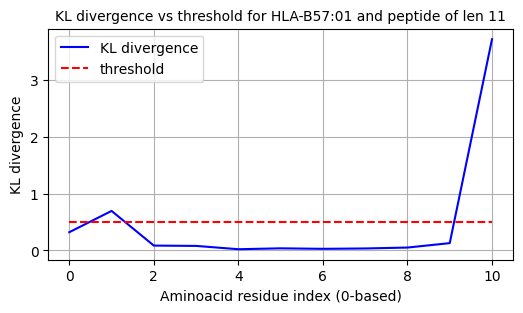

In [4]:
def build_KL_plot(hla, peptide):
    combination = f'{hla}_{len(peptide)}'
    KL = np.load(f'../datasets/KL/KL-{combination}.npy')

    fig = plt.figure(figsize=(6,3))
    fig = plt.plot([i for i in range(len(peptide))], KL, 'b', label = 'KL divergence')
    fig = plt.plot([0, len(peptide)-1], [TEST_THRESHOLD, TEST_THRESHOLD],'r', linestyle = '--', label = 'threshold')
    fig = plt.ylabel('KL divergence')
    fig = plt.xlabel('Aminoacid residue index (0-based)')
    fig = plt.title(f'KL divergence vs threshold for {hla} and peptide of len {len(peptide)}', fontsize = 10)
    fig = plt.legend()
    fig = plt.grid()
    
    print(KL)


TEST_THRESHOLD = 0.5

build_KL_plot('HLA-B57:01','AALDSRKNYNW')

A [0.08950143 0.15035565 0.08578257 0.08882528 0.06989285 0.06245512
 0.06887862 0.05738393 0.06414551 0.05434122 0.00565785]
R [0.119351   0.01792731 0.05545407 0.04395939 0.04362131 0.05038289
 0.05139713 0.06052526 0.07607689 0.06187757 0.00474223]
N [0.01452066 0.01452066 0.03041038 0.02871998 0.03886235 0.03886235
 0.03074845 0.03953851 0.03886235 0.03751003 0.00336406]
D [0.0076394  0.01710561 0.03874267 0.06680322 0.06240819 0.06680322
 0.05226582 0.04449001 0.03569996 0.02285295 0.00324437]
C [0.00445523 0.00851218 0.01392144 0.00885026 0.01121681 0.00952642
 0.00783602 0.00580755 0.00749794 0.00885026 0.00073636]
Q [0.03840162 0.02217383 0.03806354 0.04245857 0.03975394 0.04178241
 0.04448704 0.04955823 0.06477178 0.05665789 0.00256525]
E [0.01619301 0.01889764 0.03715391 0.06791909 0.06420022 0.06352407
 0.05405786 0.05067707 0.06690486 0.04932475 0.00537448]
G [0.0414146  0.03904805 0.04580963 0.05967087 0.06474205 0.07184171
 0.06102318 0.06575629 0.04006229 0.04614771 0.00

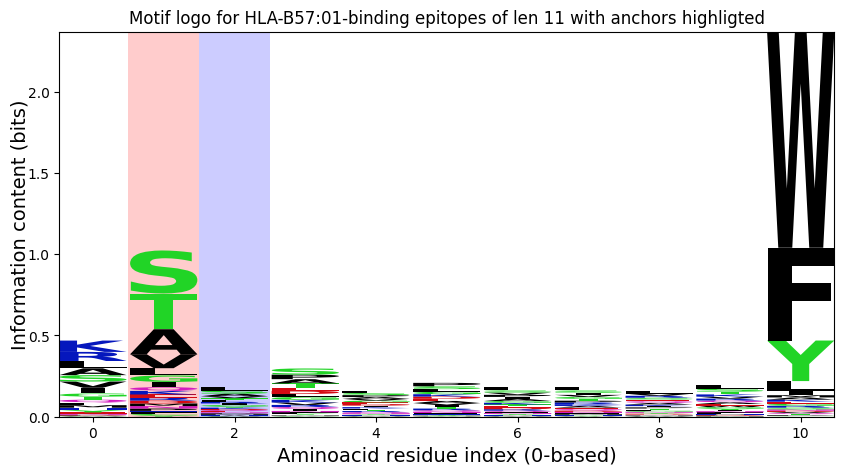

In [ ]:
ALPHABET = ''.join(['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
                         'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V'])



def build_logo(hla, peptide, coords):
    combination = f'{hla}_{len(peptide)}'
    pwm = np.load(f'../datasets/PWM/PWM-{combination}.npy')
    ppm = np.load(f'../datasets/PPM/PPM-{combination}.npy')

    #for i in range(len(ALPHABET)):
    #    print(ALPHABET[i], ppm[i])

    #
    canonical_anchors = 1, len(peptide)-1 #P2, Pomega (0 based notation)
    #


    ppm_matrix = pd.DataFrame({ALPHABET[i]: ppm[i] for i in range(len(ALPHABET))})


    information_mat = logomaker.transform_matrix(ppm_matrix, 
                                from_type='probability', 
                                to_type='information')
    
    logo = logomaker.Logo(information_mat, figsize=(10,5))

    for i in coords:
        if i in canonical_anchors:
            logo.highlight_position(i, color = 'red', alpha = 0.2)
        else:
            logo.highlight_position(i, color = 'blue', alpha = 0.2)

    logo.ax.set_xlabel('Aminoacid residue index (0-based)',fontsize=14)
    logo.ax.set_ylabel("Information content (bits)", labelpad=-1,fontsize=14)
    logo.ax.set_title(f'Motif logo for {hla}-binding epitopes of len {len(peptide)} with anchors highligted')





    



        


build_logo('HLA-B57:01','AALDSRKNYNW', [1,2] )


1.000002